# Baseline CNN 🚀

### Imports

In [16]:
import os
import random
import time
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

warnings.filterwarnings("ignore")

In [17]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Configuration

In [18]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", DEVICE)

TRAIN_DIR = "../data/raw/Lung_Disease_Dataset/train"
VAL_DIR = "../data/raw/Lung_Disease_Dataset/val"
TEST_DIR = "../data/raw/Lung_Disease_Dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 32

# Train longer and let Early Stopping decide when to stop
EPOCHS = 40
LEARNING_RATE = 3e-4

NUM_CLASSES = 5

# Checkpoint score weighting
RECALL_WEIGHT = 0.6
F1_WEIGHT = 0.4

MODEL_SAVE_PATH = "../models/Baseline/baseline_cnn_best.pth"
HISTORY_SAVE_PATH = "../models/Baseline/baseline_cnn_history.csv"

Using Device: cuda


### Transforms

In [19]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(7),

    transforms.RandomAffine(
        degrees=5,
        translate=(0.03, 0.03),
        scale=(0.98, 1.02),
        shear=2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Dataset & DataLoaders

In [20]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']
Train: 6054
Val: 2016
Test: 2025


In [22]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.03
)

### Baseline CNN

In [23]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)

        return x

### Initialize Model

In [24]:
NUM_CLASSES = len(train_dataset.classes)

print("Classes:", train_dataset.classes)
print("Number of Classes:", NUM_CLASSES)


Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']
Number of Classes: 5


In [25]:
model = BaselineCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

print(model)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout2d(p=0.15, inplace=False)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Conv2d(128, 256, kernel_size=(3, 3), stri

### Loss & Optimizer

In [26]:
import torch.optim as optim
import torch.nn as nn

# Balanced dataset → CrossEntropy is more appropriate than Focal Loss
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.03
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scaler = GradScaler()

### Imports for Metrics

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


### Training Function

Uses AMP (`autocast` + `GradScaler`), gradient clipping, and MixUp (applied with probability `MIXUP_PROB = 0.5`).

In [28]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return epoch_loss, accuracy, precision, recall, f1

### Validation Function

In [29]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return epoch_loss, accuracy, precision, recall, f1

### Scheduler + Early Stopping

In [30]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,          # changed from 3
    min_lr=1e-6
)

EARLY_STOPPING_PATIENCE = 8   # changed from 10

best_score = -float("inf")
early_stop_counter = 0

best_model_weights = deepcopy(model.state_dict())

### History

In [31]:
history = {
    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "val_score": []
}


### Training Loop

Checkpoint selection uses `score = 0.6 * recall + 0.4 * f1` rather than F1 alone, to weight recall higher (more important to avoid missing positive disease cases).

In [32]:
best_score = -float("inf")
early_stop_counter = 0

best_model_weights = deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    print("\n" + "=" * 70)
    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print("=" * 70)

    # ==========================
    # Train
    # ==========================
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE
    )

    # ==========================
    # Validation
    # ==========================
    val_loss, val_acc, val_prec, val_rec, val_f1 = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    # Weighted validation score
    val_score = (
        RECALL_WEIGHT * val_rec +
        F1_WEIGHT * val_f1
    )

    # Scheduler step
    scheduler.step(val_score)

    # ==========================
    # Save history
    # ==========================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_prec)
    history["val_precision"].append(val_prec)

    history["train_recall"].append(train_rec)
    history["val_recall"].append(val_rec)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_score"].append(val_score)

    # ==========================
    # Print Metrics
    # ==========================
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Validation Acc  : {val_acc:.4f}")

    print(f"Train Precision : {train_prec:.4f}")
    print(f"Validation Prec : {val_prec:.4f}")

    print(f"Train Recall    : {train_rec:.4f}")
    print(f"Validation Rec  : {val_rec:.4f}")

    print(f"Train F1        : {train_f1:.4f}")
    print(f"Validation F1   : {val_f1:.4f}")

    print(f"Validation Score: {val_score:.4f}")
    print(f"Learning Rate   : {optimizer.param_groups[0]['lr']:.2e}")

    # ==========================
    # Save Best Model
    # ==========================
    if val_score > best_score:

        best_score = val_score
        early_stop_counter = 0

        best_model_weights = deepcopy(model.state_dict())

        torch.save(best_model_weights, MODEL_SAVE_PATH)

        print("✅ New Best Model Saved!")

    else:

        early_stop_counter += 1

        print(
            f"No Improvement "
            f"({early_stop_counter}/{EARLY_STOPPING_PATIENCE})"
        )

    # ==========================
    # Early Stopping
    # ==========================
    if early_stop_counter >= EARLY_STOPPING_PATIENCE:

        print("\n🛑 Early stopping triggered.")
        break

print("\n" + "=" * 70)
print("Training Completed!")
print(f"Best Validation Score : {best_score:.4f}")
print("=" * 70)

# Load best model
model.load_state_dict(best_model_weights)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_SAVE_PATH, index=False)

print(f"Training history saved to: {HISTORY_SAVE_PATH}")


Epoch [1/40]
Train Loss      : 1.0870
Validation Loss : 0.9360
Train Accuracy  : 0.5850
Validation Acc  : 0.6493
Train Precision : 0.5803
Validation Prec : 0.6846
Train Recall    : 0.5843
Validation Rec  : 0.6491
Train F1        : 0.5816
Validation F1   : 0.6527
Validation Score: 0.6505
Learning Rate   : 3.00e-04
✅ New Best Model Saved!

Epoch [2/40]
Train Loss      : 0.8698
Validation Loss : 1.0064
Train Accuracy  : 0.6635
Validation Acc  : 0.6379
Train Precision : 0.6551
Validation Prec : 0.6718
Train Recall    : 0.6629
Validation Rec  : 0.6378
Train F1        : 0.6578
Validation F1   : 0.6313
Validation Score: 0.6352
Learning Rate   : 3.00e-04
No Improvement (1/8)

Epoch [3/40]
Train Loss      : 0.8105
Validation Loss : 0.8404
Train Accuracy  : 0.6994
Validation Acc  : 0.6875
Train Precision : 0.6919
Validation Prec : 0.7479
Train Recall    : 0.6986
Validation Rec  : 0.6871
Train F1        : 0.6944
Validation F1   : 0.7013
Validation Score: 0.6928
Learning Rate   : 3.00e-04
✅ New B

In [33]:
import os

print(os.path.exists("../models"))
print(MODEL_SAVE_PATH)


True
../models/Baseline/baseline_cnn_best.pth


In [34]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_SAVE_PATH,
    index=False
)

print(f"History saved to: {HISTORY_SAVE_PATH}")


History saved to: ../models/Baseline/baseline_cnn_history.csv


## Reports

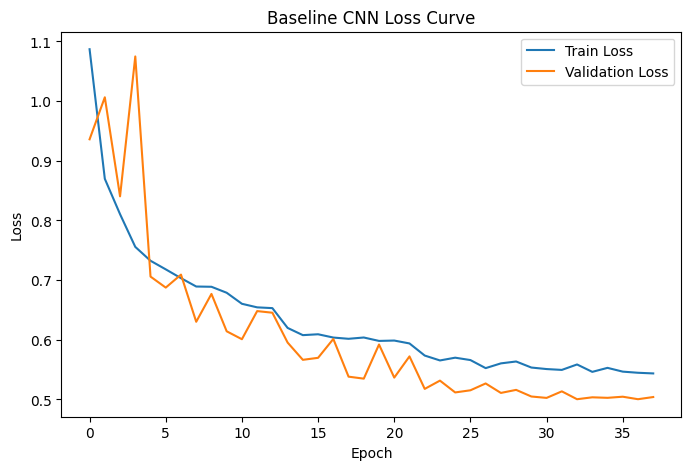

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss Curve")
plt.legend()

plt.savefig(
    "../models/Baseline/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


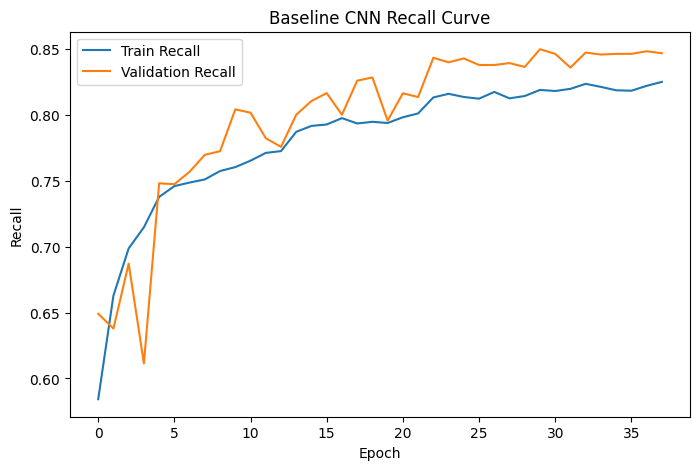

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history["train_recall"], label="Train Recall")
plt.plot(history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Baseline CNN Recall Curve")
plt.legend()

plt.savefig(
    "../models/Baseline/recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [37]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


In [38]:
class_names = train_dataset.classes

print(class_names)


['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


In [39]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

with open(
    "../models/Baseline/classification_report.txt",
    "w"
) as f:
    f.write(report)


                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.70      0.77      0.74       403
Corona Virus Disease       0.97      0.91      0.94       407
              Normal       0.87      0.94      0.90       404
        Tuberculosis       0.95      0.98      0.96       408
     Viral Pneumonia       0.72      0.60      0.65       403

            accuracy                           0.84      2025
           macro avg       0.84      0.84      0.84      2025
        weighted avg       0.84      0.84      0.84      2025



In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_acc = accuracy_score(
    all_labels,
    all_preds
)

test_precision = precision_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")


Accuracy  : 0.8425
Precision : 0.8412
Recall    : 0.8419
F1 Score  : 0.8397


In [41]:
with open(
    "../models/Baseline/metrics.txt",
    "w"
) as f:

    f.write(f"Accuracy  : {test_acc:.4f}\n")
    f.write(f"Precision : {test_precision:.4f}\n")
    f.write(f"Recall    : {test_recall:.4f}\n")
    f.write(f"F1 Score  : {test_f1:.4f}\n")


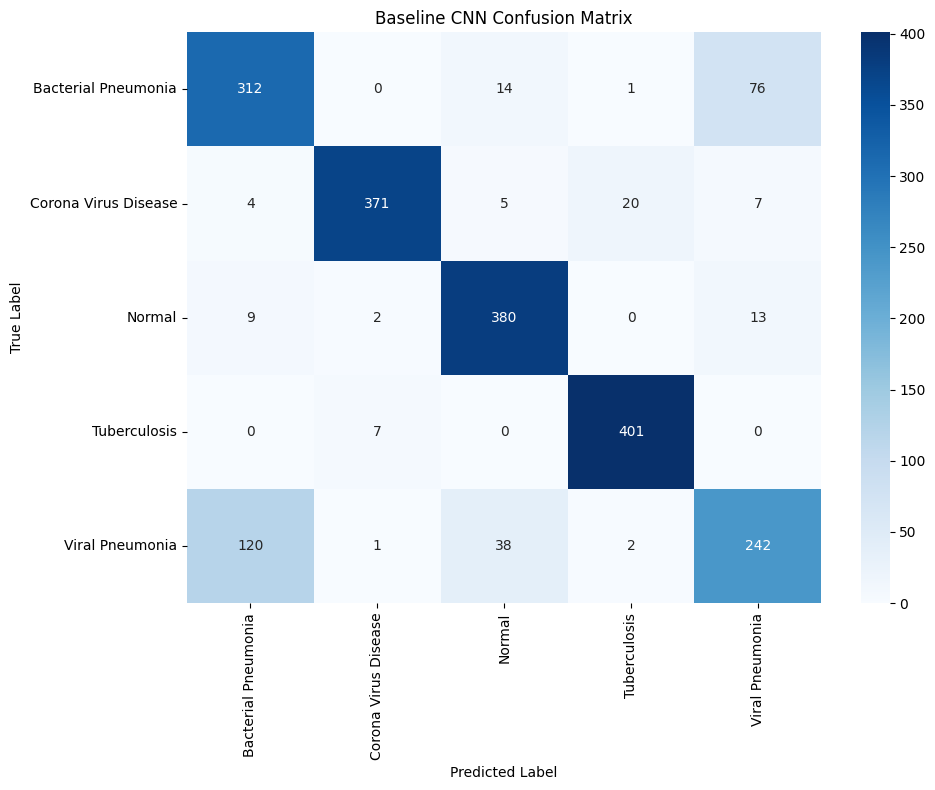

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "../models/Baseline/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
